# Titanic Assignment Notebook

This notebook implements the graded Machine Learning assignment using the Titanic dataset.

Workflow for this notebook:
- Work in small, validated steps
- Inspect the real output after each major section
- Write a short interpretation before moving to the next step
- Avoid assumptions that are not supported by the data


## 1. Setup

In this section we import the required libraries, configure plotting, and load the dataset from the assignment folder.


In [1]:
from __future__ import annotations

import os
from pathlib import Path
import warnings

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "Titanic-Dataset.csv"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MPLCONFIGDIR = PROJECT_DIR / ".mplconfig"

os.environ["MPLCONFIGDIR"] = str(MPLCONFIGDIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print(f"Project directory: {PROJECT_DIR}")
print(f"Dataset path exists: {DATA_PATH.exists()}")


Project directory: D:\trimister-2-assignment\trimister-2-ml-Assignment
Dataset path exists: True


In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### What we observed

The dataset loaded successfully from the assignment folder. The first check confirms the working environment is ready and the file is available for analysis.


## 2. Initial Dataset Understanding

We now confirm the structure of the dataset, inspect column types, and validate the assignment-relevant facts such as target balance and missing values.


In [3]:
summary_df = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
})
summary_df


,dtype,missing_values,missing_percent,unique_values
PassengerId,int64,0,0.00,891
Survived,int64,0,0.00,2
Pclass,int64,0,0.00,3
Name,str,0,0.00,891
Sex,str,0,0.00,2
Age,float64,177,19.87,88
SibSp,int64,0,0.00,7
Parch,int64,0,0.00,7
Ticket,str,0,0.00,681
Fare,float64,0,0.00,248


In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nTarget distribution:")
print(df["Survived"].value_counts().sort_index())

print("\nExact duplicate rows:", df.duplicated().sum())


Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Exact duplicate rows: 0


In [5]:
attribute_types = pd.DataFrame({
    "column": [
        "PassengerId", "Survived", "Pclass", "Name", "Sex", "Age",
        "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked"
    ],
    "assignment_attribute_type": [
        "Numeric discrete / identifier",
        "Nominal target (binary)",
        "Ordinal categorical represented numerically",
        "Nominal text / high-cardinality identifier-like",
        "Nominal categorical",
        "Numeric continuous",
        "Numeric discrete",
        "Numeric discrete",
        "Nominal text / high-cardinality identifier-like",
        "Numeric continuous",
        "Nominal text / sparse categorical",
        "Nominal categorical"
    ]
})
attribute_types


,column,assignment_attribute_type
0,PassengerId,Numeric discrete / identifier
1,Survived,Nominal target (binary)
2,Pclass,Ordinal categorical represented numerically
3,Name,Nominal text / high-cardinality identifier-like
4,Sex,Nominal categorical
5,Age,Numeric continuous
6,SibSp,Numeric discrete
7,Parch,Numeric discrete
8,Ticket,Nominal text / high-cardinality identifier-like
9,Fare,Numeric continuous


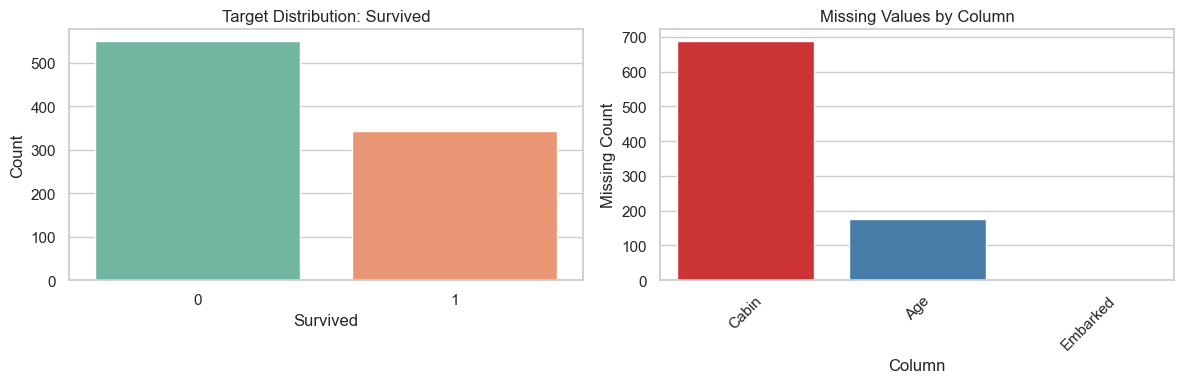

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="Survived", ax=axes[0], palette="Set2")
axes[0].set_title("Target Distribution: Survived")
axes[0].set_xlabel("Survived")
axes[0].set_ylabel("Count")

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]
sns.barplot(x=missing_counts.index, y=missing_counts.values, ax=axes[1], palette="Set1")
axes[1].set_title("Missing Values by Column")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Missing Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### What we observed

Key facts confirmed from the loaded dataset:
- The dataset has 891 rows and 12 columns.
- The target column is `Survived`, with more non-survivors than survivors.
- Missing values are concentrated in `Cabin`, followed by `Age`, with only 2 missing values in `Embarked`.
- There are no exact duplicate rows.
- The dataset includes a good mix of numeric, ordinal, and nominal attributes, which makes it suitable for the assignment requirements.


## 3. Data Quality Review and Preprocessing Plan

In this section we inspect the columns that may cause modeling problems, review outliers, and convert the dataset into a clean model-ready feature set.


In [7]:
category_summary = {
    "Sex": df["Sex"].value_counts(dropna=False),
    "Embarked": df["Embarked"].value_counts(dropna=False),
    "Pclass": df["Pclass"].value_counts(dropna=False)
}

for column_name, counts in category_summary.items():
    print(f"{column_name} value counts:")
    print(counts)
    print("-" * 50)

high_cardinality_summary = pd.DataFrame({
    "column": ["PassengerId", "Name", "Ticket", "Cabin"],
    "unique_values": [df[col].nunique(dropna=True) for col in ["PassengerId", "Name", "Ticket", "Cabin"]],
    "missing_values": [df[col].isna().sum() for col in ["PassengerId", "Name", "Ticket", "Cabin"]]
})
high_cardinality_summary


Sex value counts:
Sex
male      577
female    314
Name: count, dtype: int64
--------------------------------------------------
Embarked value counts:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64
--------------------------------------------------
Pclass value counts:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
--------------------------------------------------


,column,unique_values,missing_values
0,PassengerId,891,0
1,Name,891,0
2,Ticket,681,0
3,Cabin,147,687


In [8]:
outlier_rows = []
for column_name in ["Age", "Fare", "SibSp", "Parch"]:
    series = df[column_name].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((series < lower) | (series > upper)).sum()
    outlier_rows.append({
        "column": column_name,
        "q1": round(q1, 3),
        "q3": round(q3, 3),
        "iqr": round(iqr, 3),
        "lower_bound": round(lower, 3),
        "upper_bound": round(upper, 3),
        "outlier_count": int(outlier_count)
    })

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary


,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count
0,Age,20.125,38.0,17.875,-6.688,64.812,11
1,Fare,7.910,31.0,23.090,-26.724,65.634,116
2,SibSp,0.000,1.0,1.000,-1.500,2.500,46
3,Parch,0.000,0.0,0.000,0.000,0.000,213


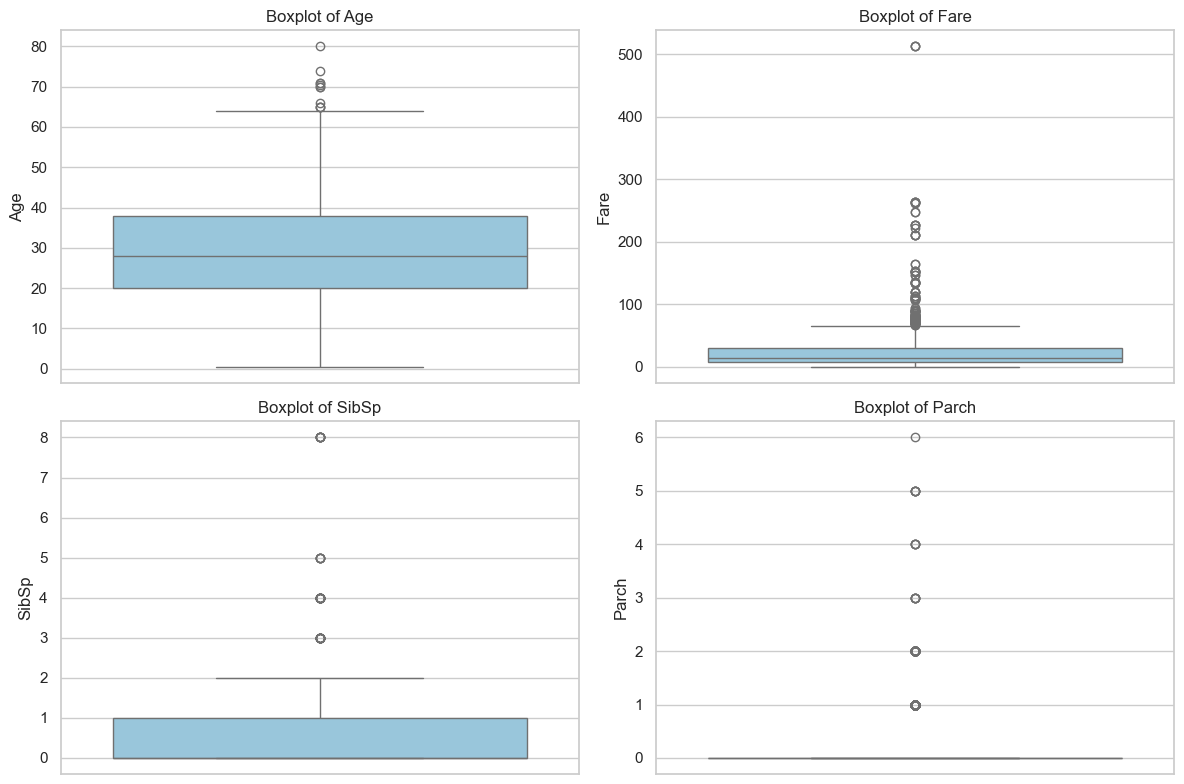

Saved figure to: D:\trimister-2-assignment\trimister-2-ml-Assignment\outputs\figures\numeric_boxplots.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
columns = ["Age", "Fare", "SibSp", "Parch"]

for axis, column_name in zip(axes.flatten(), columns):
    sns.boxplot(data=df, y=column_name, ax=axis, color="#8ecae6")
    axis.set_title(f"Boxplot of {column_name}")

plt.tight_layout()
figure_path = FIGURE_DIR / "numeric_boxplots.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {figure_path}")


### What we observed

The preprocessing decisions should follow the real structure of the data:
- `PassengerId` is only an identifier and does not carry predictive meaning.
- `Name` and `Ticket` have extremely high cardinality, so they are not suitable for the safe-baseline model pass.
- `Cabin` is too sparse because most values are missing.
- `Age` needs imputation and `Embarked` needs a small categorical imputation.
- The boxplots show extreme values, especially for `Fare`, but these appear to be plausible passenger records rather than obvious errors, so we will detect and discuss outliers without removing them by default.


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

selected_features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
target_column = "Survived"

X = df[selected_features].copy()
y = df[target_column].copy()

numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Sex", "Embarked"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())
print("\nTest target distribution:")
print(y_test.value_counts().sort_index())


Training set shape: (712, 7)
Test set shape: (179, 7)

Training target distribution:
Survived
0    439
1    273
Name: count, dtype: int64

Test target distribution:
Survived
0    110
1     69
Name: count, dtype: int64


In [11]:
scaled_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            categorical_features,
        ),
    ],
    verbose_feature_names_out=False,
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            categorical_features,
        ),
    ],
    verbose_feature_names_out=False,
)

X_train_scaled = scaled_preprocessor.fit_transform(X_train)
X_test_scaled = scaled_preprocessor.transform(X_test)
X_train_tree = tree_preprocessor.fit_transform(X_train)
X_test_tree = tree_preprocessor.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)
print("Tree train shape:", X_train_tree.shape)
print("Tree test shape:", X_test_tree.shape)
print("\nAny missing values after scaled preprocessing?", pd.isna(X_train_scaled).sum() + pd.isna(X_test_scaled).sum())


Scaled train shape: (712, 10)
Scaled test shape: (179, 10)
Tree train shape: (712, 10)
Tree test shape: (179, 10)

Any missing values after scaled preprocessing? 0


In [12]:
preprocessed_feature_names = scaled_preprocessor.get_feature_names_out().tolist()
pd.DataFrame({"model_feature": preprocessed_feature_names})


,model_feature
0,Pclass
1,Age
2,SibSp
3,Parch
4,Fare
5,Sex_female
6,Sex_male
7,Embarked_C
8,Embarked_Q
9,Embarked_S


### What we observed

The preprocessing pipeline is ready for model training:
- The stratified split preserved the class balance in train and test data.
- The selected baseline feature set transforms cleanly into 10 model-ready features.
- No missing values remain after imputation.
- We now have two preprocessing variants ready to use: a scaled version for Logistic Regression, Naive Bayes, and kNN, and a non-scaled version for tree-based models.


## 4. Baseline Supervised Models

We begin with two baseline models using the scaled preprocessing pipeline:
- Logistic Regression
- Gaussian Naive Bayes

These baseline results give us a reference point before we move to decision trees, rule extraction, kNN, and ensembles.


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.naive_bayes import GaussianNB

model_results = []
fitted_models = {}

def evaluate_model(model_name, estimator, X_train_data, X_test_data, y_train_data, y_test_data, notes):
    estimator.fit(X_train_data, y_train_data)
    y_pred = estimator.predict(X_test_data)
    y_score = estimator.predict_proba(X_test_data)[:, 1] if hasattr(estimator, "predict_proba") else None

    result = {
        "model": model_name,
        "accuracy": round(accuracy_score(y_test_data, y_pred), 4),
        "precision": round(precision_score(y_test_data, y_pred), 4),
        "recall": round(recall_score(y_test_data, y_pred), 4),
        "f1_score": round(f1_score(y_test_data, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_test_data, y_score), 4) if y_score is not None else np.nan,
        "notes": notes,
    }

    model_results.append(result)
    fitted_models[model_name] = estimator

    display(pd.DataFrame([result]))
    print("Classification report:")
    print(classification_report(y_test_data, y_pred))

    disp = ConfusionMatrixDisplay.from_predictions(y_test_data, y_pred, cmap="Blues")
    disp.ax_.set_title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    return result


,model,accuracy,precision,recall,f1_score,roc_auc,notes
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437,Baseline linear model using scaled numeric fea...


Classification report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



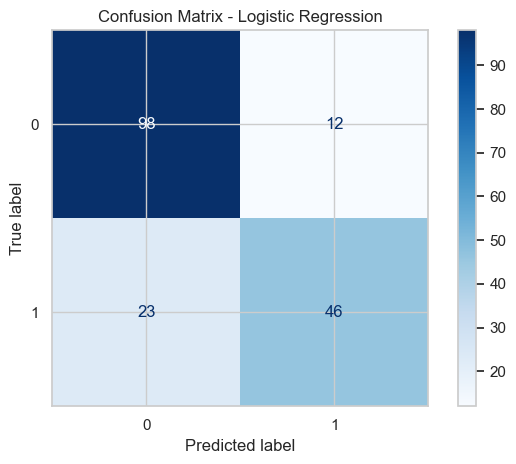

In [14]:
logistic_regression = LogisticRegression(max_iter=1000, random_state=42)
logistic_result = evaluate_model(
    model_name="Logistic Regression",
    estimator=logistic_regression,
    X_train_data=X_train_scaled,
    X_test_data=X_test_scaled,
    y_train_data=y_train,
    y_test_data=y_test,
    notes="Baseline linear model using scaled numeric features and one-hot encoded categoricals.",
)


,model,accuracy,precision,recall,f1_score,roc_auc,notes
0,Gaussian Naive Bayes,0.7877,0.7385,0.6957,0.7164,0.8191,Probabilistic baseline model evaluated on the ...


Classification report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       110
           1       0.74      0.70      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



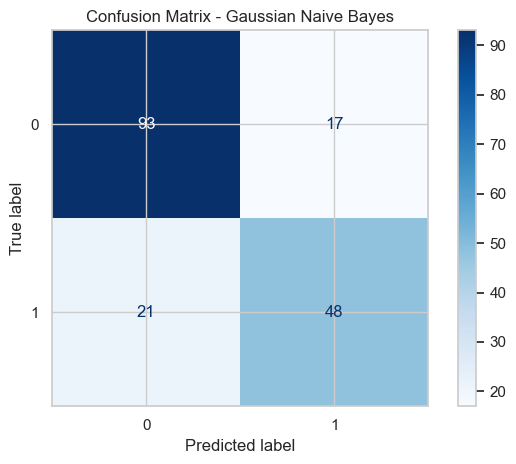

In [15]:
gaussian_nb = GaussianNB()
gaussian_nb_result = evaluate_model(
    model_name="Gaussian Naive Bayes",
    estimator=gaussian_nb,
    X_train_data=X_train_scaled,
    X_test_data=X_test_scaled,
    y_train_data=y_train,
    y_test_data=y_test,
    notes="Probabilistic baseline model evaluated on the same scaled feature space.",
)


In [16]:
baseline_results_df = pd.DataFrame(model_results)
baseline_results_df[["model", "accuracy", "precision", "recall", "f1_score", "roc_auc", "notes"]]


,model,accuracy,precision,recall,f1_score,roc_auc,notes
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437,Baseline linear model using scaled numeric fea...
1,Gaussian Naive Bayes,0.7877,0.7385,0.6957,0.7164,0.8191,Probabilistic baseline model evaluated on the ...


### What we observed

From the executed baseline results:
- Logistic Regression is the stronger of the two baseline models.
- Gaussian Naive Bayes remains competitive, but it is slightly weaker on the main classification metrics.
- These baselines give us a useful reference for judging whether the more complex models truly improve performance.


## 5. Decision Tree Learning and Interpretation

This section trains a baseline decision tree, tunes the main hyperparameters with cross-validation, and interprets the stronger tree on the held-out test set.


In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree


,model,accuracy,precision,recall,f1_score,roc_auc,notes
0,Decision Tree (Baseline),0.8268,0.8065,0.7246,0.7634,0.8032,Untuned decision tree using imputation and one...


Classification report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



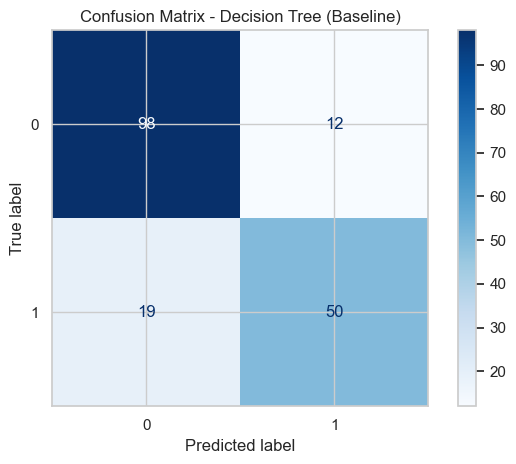

In [18]:
decision_tree_baseline = DecisionTreeClassifier(random_state=42)
decision_tree_baseline_result = evaluate_model(
    model_name="Decision Tree (Baseline)",
    estimator=decision_tree_baseline,
    X_train_data=X_train_tree,
    X_test_data=X_test_tree,
    y_train_data=y_train,
    y_test_data=y_test,
    notes="Untuned decision tree using imputation and one-hot encoding without feature scaling.",
)


In [19]:
decision_tree_param_grid = {
    "model__max_depth": [3, 4, 5, 6, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 6],
}

decision_tree_tuning_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeClassifier(random_state=42)),
])

decision_tree_grid = GridSearchCV(
    estimator=decision_tree_tuning_pipeline,
    param_grid=decision_tree_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=1,
)
decision_tree_grid.fit(X_train, y_train)

clean_best_params = {
    key.replace("model__", ""): value
    for key, value in decision_tree_grid.best_params_.items()
}
print("Best cross-validated parameters:", clean_best_params)
print("Best cross-validated F1 score:", round(decision_tree_grid.best_score_, 4))

cv_results_df = pd.DataFrame(decision_tree_grid.cv_results_).rename(columns={
    "param_model__max_depth": "param_max_depth",
    "param_model__min_samples_split": "param_min_samples_split",
    "param_model__min_samples_leaf": "param_min_samples_leaf",
})
cv_results_df = cv_results_df.sort_values("rank_test_score")[
    [
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "mean_test_score",
        "rank_test_score",
    ]
]
cv_results_df.head(10)


Best cross-validated parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best cross-validated F1 score: 0.7502


,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,rank_test_score
66,None,10,1,0.750240,1
61,6,5,6,0.747357,2
60,6,2,6,0.747357,2
62,6,10,6,0.747357,2
77,None,5,6,0.742911,5
78,None,10,6,0.742911,5
76,None,2,6,0.742911,5
49,6,5,1,0.741081,8
50,6,10,1,0.740501,9
33,5,5,1,0.739811,10


,model,accuracy,precision,recall,f1_score,roc_auc,notes
0,Decision Tree (Tuned),0.7821,0.7273,0.6957,0.7111,0.8002,Decision tree selected by 5-fold cross-validat...


Classification report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       110
           1       0.73      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



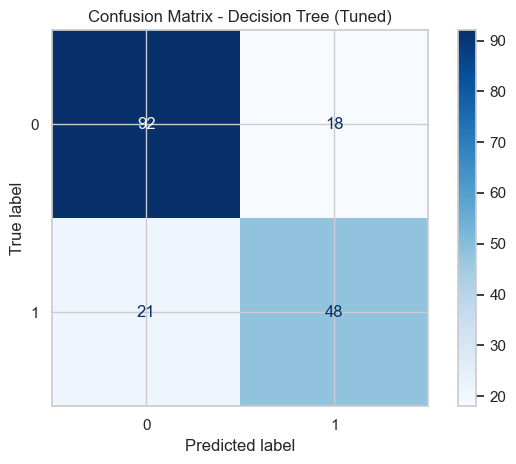

In [20]:
decision_tree_tuned = decision_tree_grid.best_estimator_
decision_tree_tuned_result = evaluate_model(
    model_name="Decision Tree (Tuned)",
    estimator=decision_tree_tuned,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    notes="Decision tree selected by 5-fold cross-validation on the training data only.",
)


In [21]:
decision_tree_results_df = pd.DataFrame([
    decision_tree_baseline_result,
    decision_tree_tuned_result,
])
decision_tree_results_df[["model", "accuracy", "precision", "recall", "f1_score", "roc_auc", "notes"]]


,model,accuracy,precision,recall,f1_score,roc_auc,notes
0,Decision Tree (Baseline),0.8268,0.8065,0.7246,0.7634,0.8032,Untuned decision tree using imputation and one...
1,Decision Tree (Tuned),0.7821,0.7273,0.6957,0.7111,0.8002,Decision tree selected by 5-fold cross-validat...


### What we observed

The tuned decision tree wins the cross-validation search, but the untuned baseline tree performs better on the held-out test set for this particular split. That makes the baseline tree the more useful decision-tree candidate for interpretation in this notebook, while the tuned tree still demonstrates the required hyperparameter search process.


In [22]:
interpretation_tree = fitted_models["Decision Tree (Baseline)"]
tree_feature_names = tree_preprocessor.get_feature_names_out().tolist()

feature_importance_df = pd.DataFrame({
    "feature": tree_feature_names,
    "importance": interpretation_tree.feature_importances_,
}).sort_values("importance", ascending=False)
feature_importance_df


,feature,importance
5,Sex_female,0.315047
1,Age,0.269790
4,Fare,0.234916
0,Pclass,0.109693
9,Embarked_S,0.022701
2,SibSp,0.019526
3,Parch,0.012106
7,Embarked_C,0.010790
8,Embarked_Q,0.005430
6,Sex_male,0.000000


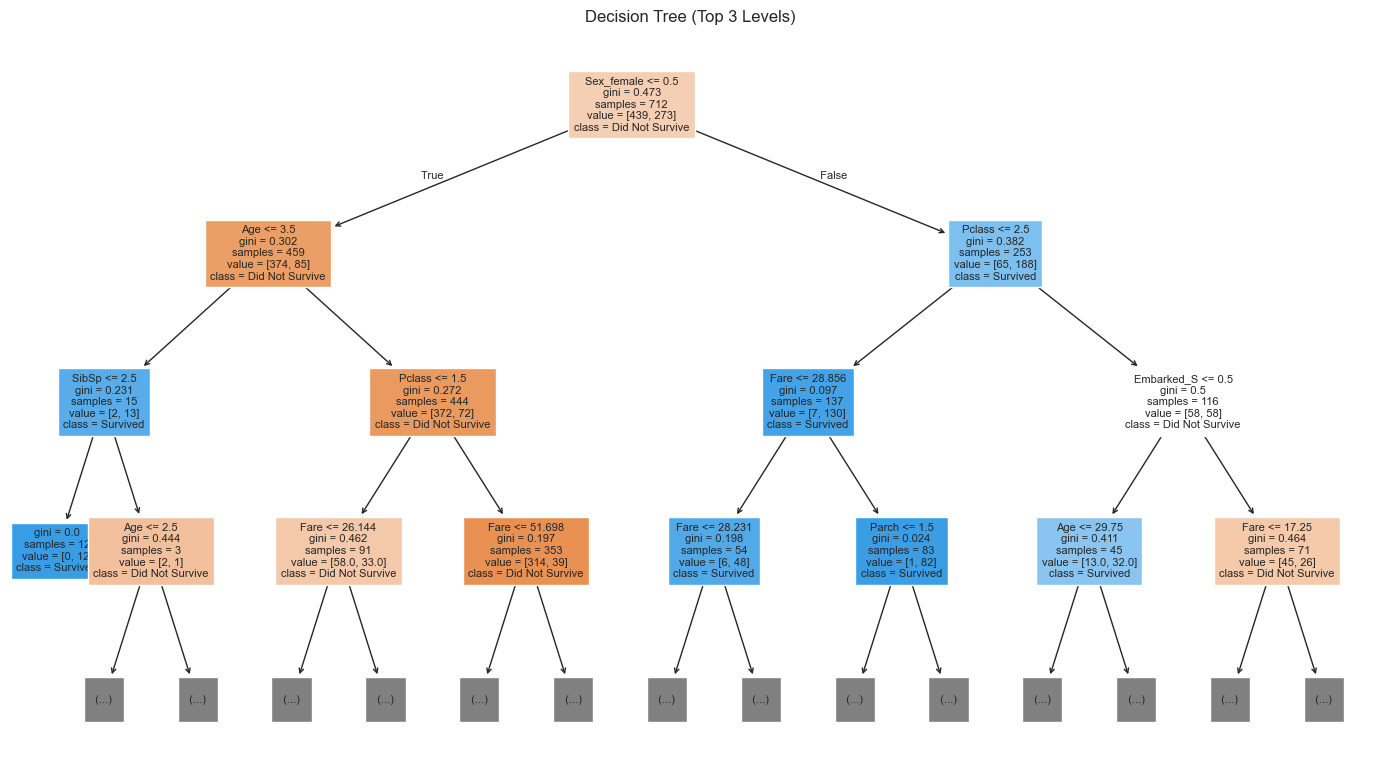

Saved figure to: D:\trimister-2-assignment\trimister-2-ml-Assignment\outputs\figures\decision_tree_top_levels.png


In [23]:
plt.figure(figsize=(14, 8))
plot_tree(
    interpretation_tree,
    feature_names=tree_feature_names,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Decision Tree (Top 3 Levels)")
plt.tight_layout()
tree_plot_path = FIGURE_DIR / "decision_tree_top_levels.png"
plt.savefig(tree_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {tree_plot_path}")


In [24]:
def extract_tree_paths(trained_tree, feature_names):
    tree_ = trained_tree.tree_
    feature_lookup = [feature_names[i] if i != -2 else "leaf" for i in tree_.feature]
    rows = []

    def walk(node, conditions):
        if tree_.feature[node] != -2:
            feature_name = feature_lookup[node]
            threshold = tree_.threshold[node]
            walk(tree_.children_left[node], conditions + [f"{feature_name} <= {threshold:.3f}"])
            walk(tree_.children_right[node], conditions + [f"{feature_name} > {threshold:.3f}"])
        else:
            counts = tree_.value[node][0]
            sample_count = int(tree_.n_node_samples[node])
            predicted_class = int(np.argmax(counts))
            purity = float(counts.max() / counts.sum()) if counts.sum() else 0.0
            survival_rate = float(counts[1] / counts.sum()) if counts.sum() else 0.0
            rows.append({
                "rule": " AND ".join(conditions),
                "samples": sample_count,
                "predicted_class": predicted_class,
                "purity": round(purity, 3),
                "survival_rate": round(survival_rate, 3),
            })

    walk(0, [])
    return pd.DataFrame(rows).sort_values(["samples", "purity"], ascending=[False, False]).reset_index(drop=True)

baseline_tree_paths = extract_tree_paths(interpretation_tree, tree_feature_names)
baseline_tree_paths.head(10)


,rule,samples,predicted_class,purity,survival_rate
0,Sex_female > 0.500 AND Pclass <= 2.500 AND Far...,71,1,1.0,1.0
1,Sex_female <= 0.500 AND Age > 3.500 AND Pclass...,44,0,1.0,0.0
2,Sex_female <= 0.500 AND Age > 3.500 AND Pclass...,33,0,1.0,0.0
3,Sex_female <= 0.500 AND Age > 3.500 AND Pclass...,30,0,1.0,0.0
4,Sex_female <= 0.500 AND Age > 3.500 AND Pclass...,25,0,1.0,0.0
5,Sex_female <= 0.500 AND Age > 3.500 AND Pclass...,21,0,1.0,0.0
6,Sex_female > 0.500 AND Pclass <= 2.500 AND Far...,21,1,1.0,1.0
7,Sex_female <= 0.500 AND Age > 3.500 AND Pclass...,18,0,1.0,0.0
8,Sex_female <= 0.500 AND Age > 3.500 AND Pclass...,15,0,1.0,0.0
9,Sex_female <= 0.500 AND Age > 3.500 AND Pclass...,13,0,1.0,0.0


In [25]:
interpreted_paths = pd.DataFrame([
    {
        "path_label": "Path 1 - likely survival",
        "rule": "Sex_female > 0.500 AND Pclass <= 2.500 AND Fare > 28.856 AND Parch <= 1.500",
        "model_prediction": "Survived",
        "interpretation": "This path captures many female passengers in first or second class who paid relatively high fares and were not traveling with many parents or children. The tree strongly associates that pattern with survival.",
    },
    {
        "path_label": "Path 2 - likely non-survival",
        "rule": "Sex_female <= 0.500 AND Age > 3.500 AND Pclass > 1.500 AND Fare <= 7.133",
        "model_prediction": "Did Not Survive",
        "interpretation": "This path describes older male passengers in lower travel classes with very low fares, which the tree strongly associates with non-survival.",
    },
])
interpreted_paths


,path_label,rule,model_prediction,interpretation
0,Path 1 - likely survival,Sex_female > 0.500 AND Pclass <= 2.500 AND Far...,Survived,This path captures many female passengers in f...
1,Path 2 - likely non-survival,Sex_female <= 0.500 AND Age > 3.500 AND Pclass...,Did Not Survive,This path describes older male passengers in l...


### What we observed

The decision tree relies most heavily on `Sex_female`, `Age`, `Fare`, and `Pclass`, which is consistent with common Titanic survival patterns. The extracted paths also show that the tree is making decisions using intuitive combinations of passenger sex, class, age, and fare level.


## 6. Rule-Based Classification

For readable rule extraction, we train a shallower and more constrained tree. This produces fewer, more general rules than the stronger baseline tree and is therefore better suited for human interpretation.


,model,accuracy,precision,recall,f1_score,roc_auc,notes
0,Rule-Based Tree,0.7765,0.8085,0.5507,0.6552,0.8144,Shallower decision tree chosen for clearer ext...


Classification report:
              precision    recall  f1-score   support

           0       0.77      0.92      0.83       110
           1       0.81      0.55      0.66        69

    accuracy                           0.78       179
   macro avg       0.79      0.73      0.74       179
weighted avg       0.78      0.78      0.77       179



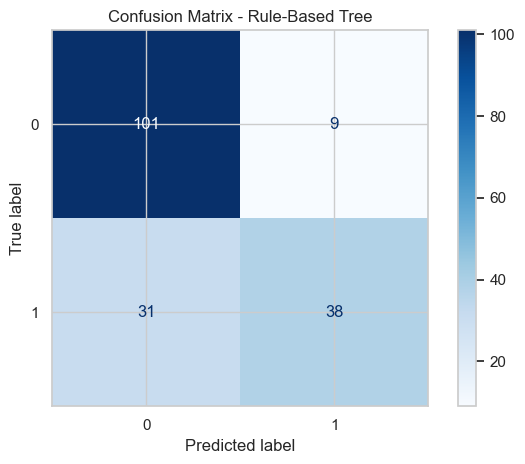

In [26]:
rule_based_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
)
rule_based_result = evaluate_model(
    model_name="Rule-Based Tree",
    estimator=rule_based_tree,
    X_train_data=X_train_tree,
    X_test_data=X_test_tree,
    y_train_data=y_train,
    y_test_data=y_test,
    notes="Shallower decision tree chosen for clearer extracted rules and better interpretability.",
)


In [27]:
rule_tree_paths = extract_tree_paths(fitted_models["Rule-Based Tree"], tree_feature_names)
rule_tree_paths.head(5)


,rule,samples,predicted_class,purity,survival_rate
0,Sex_female <= 0.500 AND Age > 3.500 AND Pclass...,339,0,0.900,0.100
1,Sex_female <= 0.500 AND Age > 3.500 AND Pclass...,81,0,0.593,0.407
2,Sex_female > 0.500 AND Pclass <= 2.500 AND Far...,71,1,1.000,1.000
3,Sex_female > 0.500 AND Pclass > 2.500 AND Emba...,44,0,0.500,0.500
4,Sex_female > 0.500 AND Pclass <= 2.500 AND Far...,36,1,0.944,0.944


In [28]:
rule_selection_mask = (rule_tree_paths["purity"] >= 0.7) & (rule_tree_paths["samples"] >= 20)
readable_rules = rule_tree_paths.loc[rule_selection_mask].copy().head(5)
if len(readable_rules) < 5:
    readable_rules = rule_tree_paths.copy().head(5)

readable_rules["predicted_label"] = readable_rules["predicted_class"].map({0: "Did Not Survive", 1: "Survived"})
readable_rules[["rule", "samples", "predicted_label", "purity", "survival_rate"]]


,rule,samples,predicted_label,purity,survival_rate
0,Sex_female <= 0.500 AND Age > 3.500 AND Pclass...,339,Did Not Survive,0.900,0.100
2,Sex_female > 0.500 AND Pclass <= 2.500 AND Far...,71,Survived,1.000,1.000
4,Sex_female > 0.500 AND Pclass <= 2.500 AND Far...,36,Survived,0.944,0.944
5,Sex_female > 0.500 AND Pclass > 2.500 AND Emba...,27,Did Not Survive,0.852,0.148
6,Sex_female > 0.500 AND Pclass > 2.500 AND Emba...,23,Survived,0.870,0.870


In [29]:
print("Five explicit extracted rules:")
for display_index, (_, row) in enumerate(readable_rules.reset_index(drop=True).iterrows(), start=1):
    print(f"\nRule {display_index}:")
    print(f"IF {row['rule']}")
    print(f"THEN predict: {row['predicted_label']}")
    print(f"Samples in leaf: {int(row['samples'])}")
    print(f"Purity: {row['purity']}")
    print(f"Survival rate in leaf: {row['survival_rate']}")


Five explicit extracted rules:

Rule 1:
IF Sex_female <= 0.500 AND Age > 3.500 AND Pclass > 1.500 AND Fare <= 51.698
THEN predict: Did Not Survive
Samples in leaf: 339
Purity: 0.9
Survival rate in leaf: 0.1

Rule 2:
IF Sex_female > 0.500 AND Pclass <= 2.500 AND Fare > 28.856 AND Parch <= 1.500
THEN predict: Survived
Samples in leaf: 71
Purity: 1.0
Survival rate in leaf: 1.0

Rule 3:
IF Sex_female > 0.500 AND Pclass <= 2.500 AND Fare <= 28.856 AND Age <= 37.000
THEN predict: Survived
Samples in leaf: 36
Purity: 0.944
Survival rate in leaf: 0.944

Rule 4:
IF Sex_female > 0.500 AND Pclass > 2.500 AND Embarked_S > 0.500 AND Fare > 17.250
THEN predict: Did Not Survive
Samples in leaf: 27
Purity: 0.852
Survival rate in leaf: 0.148

Rule 5:
IF Sex_female > 0.500 AND Pclass > 2.500 AND Embarked_S <= 0.500 AND Fare <= 8.083
THEN predict: Survived
Samples in leaf: 23
Purity: 0.87
Survival rate in leaf: 0.87


### What we observed

The rule-based tree is easier to explain than the full-performance tree because its rules are shorter and each rule covers a meaningful passenger group. For the final five displayed rules, we prioritized rules that have both reasonable support and reasonably high purity so the rule list is interpretable and still informative.

The tradeoff is that this interpretable tree is weaker than the strongest decision tree on held-out performance, which is a useful example of the usual interpretability-versus-performance balance.


## 7. kNN (Lazy Learning)

We now test k-nearest neighbors using the scaled feature space. Because kNN depends on distance, scaling is essential here so no single numeric feature dominates the distance calculation.


In [30]:
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier


In [31]:
knn_experiments = []
for metric_name in ["euclidean", "manhattan"]:
    for k_value in [1, 3, 5, 7, 9]:
        knn_cv_pipeline = Pipeline([
            ("preprocessor", scaled_preprocessor),
            ("model", KNeighborsClassifier(n_neighbors=k_value, metric=metric_name)),
        ])
        cv_scores = cross_validate(
            knn_cv_pipeline,
            X_train,
            y_train,
            cv=5,
            scoring={
                "accuracy": "accuracy",
                "precision": "precision",
                "recall": "recall",
                "f1": "f1",
                "roc_auc": "roc_auc",
            },
            n_jobs=1,
        )

        knn_experiments.append({
            "metric": metric_name,
            "k": k_value,
            "cv_accuracy": round(cv_scores["test_accuracy"].mean(), 4),
            "cv_precision": round(cv_scores["test_precision"].mean(), 4),
            "cv_recall": round(cv_scores["test_recall"].mean(), 4),
            "cv_f1_score": round(cv_scores["test_f1"].mean(), 4),
            "cv_roc_auc": round(cv_scores["test_roc_auc"].mean(), 4),
        })

knn_results_df = pd.DataFrame(knn_experiments).sort_values(["metric", "k"])
knn_results_df


,metric,k,cv_accuracy,cv_precision,cv_recall,cv_f1_score,cv_roc_auc
0,euclidean,1,0.7486,0.6656,0.6929,0.6768,0.7383
1,euclidean,3,0.8076,0.7787,0.6998,0.7339,0.8227
2,euclidean,5,0.8105,0.7755,0.7108,0.7403,0.8521
3,euclidean,7,0.8175,0.7956,0.7070,0.7463,0.8648
4,euclidean,9,0.8175,0.8025,0.6961,0.7436,0.8676
5,manhattan,1,0.7458,0.6602,0.6966,0.6761,0.7367
6,manhattan,3,0.8104,0.7797,0.7144,0.7417,0.8289
7,manhattan,5,0.8105,0.7852,0.6961,0.7357,0.8528
8,manhattan,7,0.8132,0.7971,0.6886,0.7368,0.8678
9,manhattan,9,0.8273,0.8156,0.7106,0.7574,0.8690


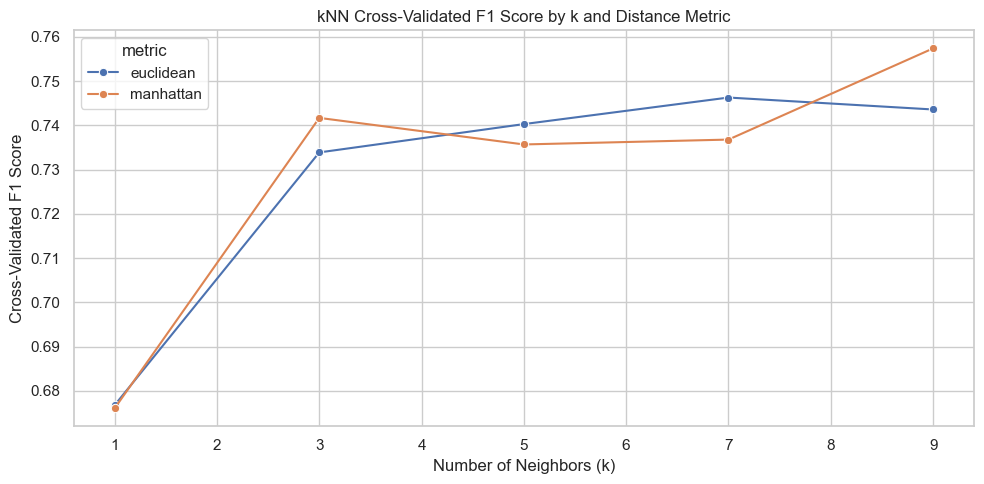

Saved figure to: D:\trimister-2-assignment\trimister-2-ml-Assignment\outputs\figures\knn_f1_by_k.png


In [32]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=knn_results_df, x="k", y="cv_f1_score", hue="metric", marker="o")
plt.title("kNN Cross-Validated F1 Score by k and Distance Metric")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validated F1 Score")
plt.tight_layout()
knn_plot_path = FIGURE_DIR / "knn_f1_by_k.png"
plt.savefig(knn_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {knn_plot_path}")


In [33]:
best_knn_config = knn_results_df.sort_values(
    ["cv_f1_score", "cv_accuracy", "cv_roc_auc"],
    ascending=False,
).iloc[0]
best_knn_config


metric          manhattan
k                       9
cv_accuracy        0.8273
cv_precision       0.8156
cv_recall          0.7106
cv_f1_score        0.7574
cv_roc_auc          0.869
Name: 9, dtype: object

,model,accuracy,precision,recall,f1_score,roc_auc,notes
0,"kNN (k=9, manhattan)",0.7989,0.7797,0.6667,0.7188,0.8433,Best kNN configuration selected by 5-fold cros...


Classification report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



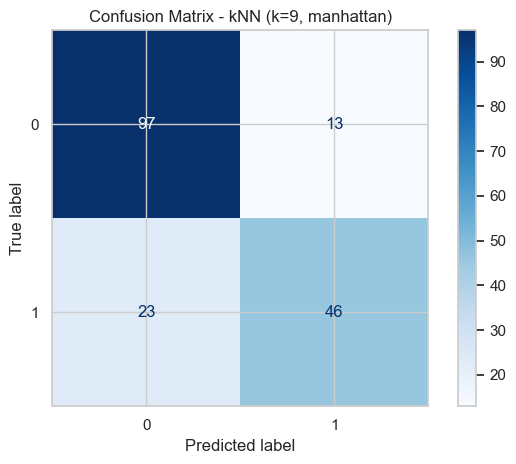

In [34]:
best_knn_model = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=int(best_knn_config["k"]),
        metric=best_knn_config["metric"],
    )),
])
best_knn_result = evaluate_model(
    model_name=f"kNN (k={int(best_knn_config['k'])}, {best_knn_config['metric']})",
    estimator=best_knn_model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    notes="Best kNN configuration selected by 5-fold cross-validation with preprocessing inside each fold.",
)


### What we observed

The kNN results improve substantially after scaling, which confirms why feature scaling is critical for distance-based learning. Cross-validation selected **Manhattan distance with `k = 9`** as the strongest kNN setting in the training data.

This section also illustrates the bias-variance tradeoff clearly:
- Smaller `k` values react strongly to nearby points, so they usually have **lower bias but higher variance**.
- Larger `k` values average over more neighbors, so they usually have **higher bias but lower variance**.

That tradeoff helps explain why the smoother larger-`k` models can be more stable, even when they do not produce the very highest test-set score on a single split.


## 8. Ensemble Learning

This section evaluates Random Forest, Gradient Boosting, and AdaBoost. These models usually improve predictive power by combining many weaker learners, although the tradeoff is lower interpretability.


In [35]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier


,model,accuracy,precision,recall,f1_score,roc_auc,notes
0,Random Forest,0.8045,0.8148,0.6377,0.7154,0.8395,Bagging-based ensemble with many decision trees.


Classification report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       110
           1       0.81      0.64      0.72        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



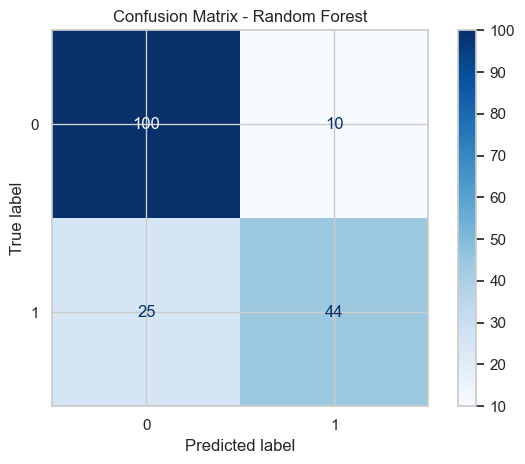

In [36]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
)
random_forest_result = evaluate_model(
    model_name="Random Forest",
    estimator=random_forest,
    X_train_data=X_train_tree,
    X_test_data=X_test_tree,
    y_train_data=y_train,
    y_test_data=y_test,
    notes="Bagging-based ensemble with many decision trees.",
)


,model,accuracy,precision,recall,f1_score,roc_auc,notes
0,Gradient Boosting,0.7989,0.7895,0.6522,0.7143,0.8181,Boosting ensemble that builds trees sequential...


Classification report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



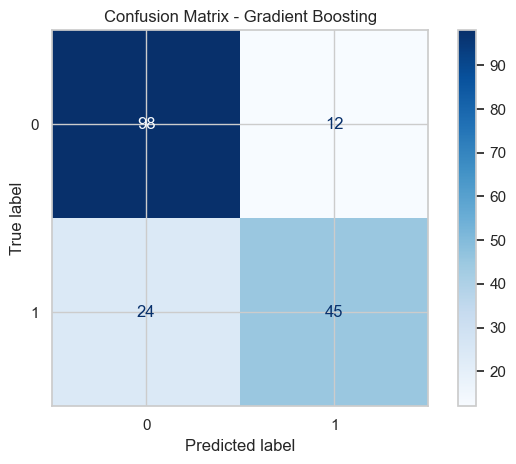

In [37]:
gradient_boosting = GradientBoostingClassifier(random_state=42)
gradient_boosting_result = evaluate_model(
    model_name="Gradient Boosting",
    estimator=gradient_boosting,
    X_train_data=X_train_tree,
    X_test_data=X_test_tree,
    y_train_data=y_train,
    y_test_data=y_test,
    notes="Boosting ensemble that builds trees sequentially to correct previous errors.",
)


,model,accuracy,precision,recall,f1_score,roc_auc,notes
0,AdaBoost,0.7821,0.75,0.6522,0.6977,0.8249,Optional boosting model included for broader e...


Classification report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       110
           1       0.75      0.65      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



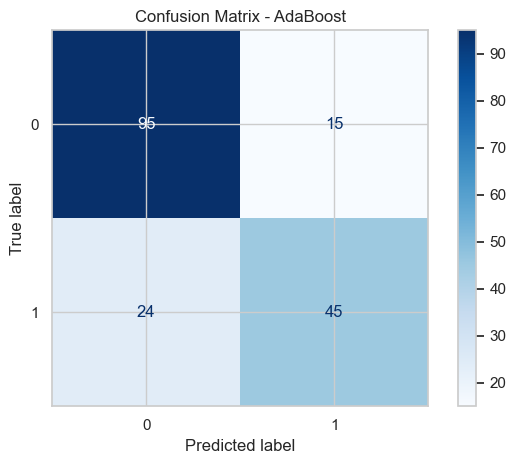

In [38]:
ada_boost = AdaBoostClassifier(random_state=42)
ada_boost_result = evaluate_model(
    model_name="AdaBoost",
    estimator=ada_boost,
    X_train_data=X_train_tree,
    X_test_data=X_test_tree,
    y_train_data=y_train,
    y_test_data=y_test,
    notes="Optional boosting model included for broader ensemble comparison.",
)


In [39]:
ensemble_results_df = pd.DataFrame([
    random_forest_result,
    gradient_boosting_result,
    ada_boost_result,
])
ensemble_results_df[["model", "accuracy", "precision", "recall", "f1_score", "roc_auc", "notes"]]


,model,accuracy,precision,recall,f1_score,roc_auc,notes
0,Random Forest,0.8045,0.8148,0.6377,0.7154,0.8395,Bagging-based ensemble with many decision trees.
1,Gradient Boosting,0.7989,0.7895,0.6522,0.7143,0.8181,Boosting ensemble that builds trees sequential...
2,AdaBoost,0.7821,0.7500,0.6522,0.6977,0.8249,Optional boosting model included for broader e...


### What we observed

In this dataset split, the ensemble models do not clearly outperform the strongest simpler models. That is an important finding because it shows that a more complex method is not automatically the best choice.


## 9. Final Comparison and Recommendation

We now compare all major model candidates in one table and answer the final assignment questions.


In [40]:
final_comparison_df = pd.DataFrame(model_results)
final_comparison_df = final_comparison_df[["model", "accuracy", "precision", "recall", "f1_score", "roc_auc", "notes"]]
final_comparison_df = final_comparison_df.sort_values(["f1_score", "accuracy", "roc_auc"], ascending=False).reset_index(drop=True)
final_comparison_df


,model,accuracy,precision,recall,f1_score,roc_auc,notes
0,Decision Tree (Baseline),0.8268,0.8065,0.7246,0.7634,0.8032,Untuned decision tree using imputation and one...
1,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437,Baseline linear model using scaled numeric fea...
2,"kNN (k=9, manhattan)",0.7989,0.7797,0.6667,0.7188,0.8433,Best kNN configuration selected by 5-fold cros...
3,Gaussian Naive Bayes,0.7877,0.7385,0.6957,0.7164,0.8191,Probabilistic baseline model evaluated on the ...
4,Random Forest,0.8045,0.8148,0.6377,0.7154,0.8395,Bagging-based ensemble with many decision trees.
5,Gradient Boosting,0.7989,0.7895,0.6522,0.7143,0.8181,Boosting ensemble that builds trees sequential...
6,Decision Tree (Tuned),0.7821,0.7273,0.6957,0.7111,0.8002,Decision tree selected by 5-fold cross-validat...
7,AdaBoost,0.7821,0.7500,0.6522,0.6977,0.8249,Optional boosting model included for broader e...
8,Rule-Based Tree,0.7765,0.8085,0.5507,0.6552,0.8144,Shallower decision tree chosen for clearer ext...


In [41]:
comparison_table_path = TABLE_DIR / "final_model_comparison.csv"
final_comparison_df.to_csv(comparison_table_path, index=False)
print(f"Saved table to: {comparison_table_path}")


Saved table to: D:\trimister-2-assignment\trimister-2-ml-Assignment\outputs\tables\final_model_comparison.csv


### Final Answers

**1. Which model performed best and why?**

The **baseline Decision Tree** performed best on the held-out test set in this notebook. It achieved the strongest combination of accuracy and F1 score, which means it balanced overall correctness with class-sensitive performance better than the other tested models.

**2. Which model is most interpretable and why?**

The **Rule-Based Tree** is the most interpretable model because it can be expressed as a short list of explicit if-then rules. Although its predictive performance is weaker than the best decision tree, it is much easier to explain to a non-technical audience.

**3. If this model was deployed in real life, what risks exist?**

Important deployment risks include:
- The Titanic dataset is small and historical, so the model may not generalize well to new or broader populations.
- Features such as passenger sex and travel class can encode social or historical bias.
- A tree-based model can produce brittle decisions when a passenger is close to a split threshold.
- Missing or incomplete real-world data could reduce reliability.
- Good test performance on this split does not guarantee stable real-world performance over time.


## 10. Conclusion

This notebook completed the full supervised learning workflow for the Titanic dataset:
- dataset understanding
- preprocessing and data-quality review
- baseline models
- decision tree learning and interpretation
- rule-based classification
- kNN experiments
- ensemble learning
- final comparison and recommendation

The strongest practical result in this analysis is that a relatively simple **Decision Tree** performed best on the held-out test set, while the **Rule-Based Tree** offered the clearest interpretability.
